In [1]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)
print("GPUs found:", tf.config.list_physical_devices("GPU"))

2026-05-08 21:13:47.379282: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778274827.609215      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778274827.675301      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778274828.218650      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778274828.218690      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778274828.218693      57 computation_placer.cc:177] computation placer alr

TensorFlow version: 2.19.0
GPUs found: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [4]:
from pathlib import Path

INPUT_DIR = Path("/kaggle/input/datasets")

zip_files = list(INPUT_DIR.rglob("*.zip"))
jpg_files = list(INPUT_DIR.rglob("*.jpg"))

print("Number of zip files:", len(zip_files))
for file in zip_files[:20]:
    print("ZIP:", file)

print("\nNumber of jpg files:", len(jpg_files))
print("First 10 jpg files:")
for file in jpg_files[:10]:
    print(file)

Number of zip files: 0

Number of jpg files: 9114
First 10 jpg files:
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H5_95a_4.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H2_23a_1.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H1_74a_23.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H1_6b_8.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H1_78b_9.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H3_5a_17.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H1_68b_7.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H1_3a_6.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H5_101a_3.jpg
/kaggle/input/datasets/andreafernandezcruz/defungi/defungi/H2_17b_1.jpg


In [5]:
import shutil
from pathlib import Path
from collections import Counter

RAW_IMAGE_DIR = Path("/kaggle/input/datasets/andreafernandezcruz/defungi/defungi")
ORGANIZED_DIR = Path("/kaggle/working/defungi_organized")

if ORGANIZED_DIR.exists():
    shutil.rmtree(ORGANIZED_DIR)

ORGANIZED_DIR.mkdir(parents=True, exist_ok=True)

prefix_to_class = {
    "H1": "C1",
    "H2": "C2",
    "H3": "C3",
    "H5": "C4",
    "H6": "C5",
}

for class_name in prefix_to_class.values():
    (ORGANIZED_DIR / class_name).mkdir(parents=True, exist_ok=True)

image_paths = list(RAW_IMAGE_DIR.glob("*.jpg"))

for image_path in image_paths:
    prefix = image_path.name.split("_")[0]
    
    if prefix in prefix_to_class:
        class_name = prefix_to_class[prefix]
        destination = ORGANIZED_DIR / class_name / image_path.name
        shutil.copy(image_path, destination)

print("Organized dataset folder:", ORGANIZED_DIR)

for class_folder in sorted(ORGANIZED_DIR.iterdir()):
    count = len(list(class_folder.glob("*.jpg")))
    print(class_folder.name, count)

Organized dataset folder: /kaggle/working/defungi_organized
C1 4404
C2 2334
C3 819
C4 818
C5 739


In [6]:
import random
import shutil
from pathlib import Path

DATA_DIR = ORGANIZED_DIR

SPLIT_DIR = Path("/kaggle/working/defungi_split")
TRAIN_DIR = SPLIT_DIR / "train"
VAL_DIR = SPLIT_DIR / "val"
TEST_DIR = SPLIT_DIR / "test"

classes = ["C1", "C2", "C3", "C4", "C5"]

if SPLIT_DIR.exists():
    shutil.rmtree(SPLIT_DIR)

TRAIN_DIR.mkdir(parents=True, exist_ok=True)
VAL_DIR.mkdir(parents=True, exist_ok=True)
TEST_DIR.mkdir(parents=True, exist_ok=True)

def split_dataset(source_dir, train_dir, val_dir, test_dir, seed=42):
    random.seed(seed)

    for class_name in classes:
        class_path = source_dir / class_name

        image_paths = [
            file for file in class_path.iterdir()
            if file.suffix.lower() in [".jpg", ".jpeg", ".png"]
        ]

        random.shuffle(image_paths)

        total = len(image_paths)

        train_end = int(total * 0.75)
        val_end = train_end + int(total * 0.15)

        train_images = image_paths[:train_end]
        val_images = image_paths[train_end:val_end]
        test_images = image_paths[val_end:]

        for images, split_folder in [
            (train_images, train_dir),
            (val_images, val_dir),
            (test_images, test_dir),
        ]:
            class_split_folder = split_folder / class_name
            class_split_folder.mkdir(parents=True, exist_ok=True)

            for image_path in images:
                destination = class_split_folder / image_path.name
                shutil.copy(image_path, destination)

        print(
            f"{class_name}: "
            f"train={len(train_images)}, "
            f"validation={len(val_images)}, "
            f"test={len(test_images)}, "
            f"total={total}"
        )

split_dataset(DATA_DIR, TRAIN_DIR, VAL_DIR, TEST_DIR)

C1: train=3303, validation=660, test=441, total=4404
C2: train=1750, validation=350, test=234, total=2334
C3: train=614, validation=122, test=83, total=819
C4: train=613, validation=122, test=83, total=818
C5: train=554, validation=110, test=75, total=739


In [8]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=True,
    seed=42
)

val_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

class_names = train_ds.class_names

AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)

print("Class names:", class_names)
print("Number of classes:", len(class_names))

Found 6834 files belonging to 5 classes.
Found 1364 files belonging to 5 classes.
Found 916 files belonging to 5 classes.
Class names: ['C1', 'C2', 'C3', 'C4', 'C5']
Number of classes: 5


In [9]:
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/final_project_outputs")

SAVED_MODELS_DIR = OUTPUT_DIR / "saved_models"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

SAVED_MODELS_DIR.mkdir(parents=True, exist_ok=True)
PLOTS_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

print("Saved models folder:", SAVED_MODELS_DIR)
print("Plots folder:", PLOTS_DIR)
print("Results folder:", RESULTS_DIR)

Saved models folder: /kaggle/working/final_project_outputs/saved_models
Plots folder: /kaggle/working/final_project_outputs/plots
Results folder: /kaggle/working/final_project_outputs/results


In [10]:
import numpy as np
import pickle
import matplotlib.pyplot as plt

from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from tensorflow.keras.applications import ResNet101, EfficientNetB0, DenseNet201
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

NUM_CLASSES = len(class_names)

data_augmentation = keras.Sequential(
    [
        layers.RandomCrop(200, 200),
        layers.Resizing(224, 224),
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.15),
        layers.RandomZoom(0.15),
        layers.RandomTranslation(0.1, 0.1),
        layers.RandomContrast(0.2),
    ],
    name="data_augmentation"
)

def build_transfer_model(base_model_class, preprocess_input_function, model_name):
    base_model = base_model_class(
        weights="imagenet",
        include_top=False,
        input_shape=(224, 224, 3)
    )

    base_model.trainable = False

    inputs = keras.Input(shape=(224, 224, 3))
    x = data_augmentation(inputs)
    x = preprocess_input_function(x)
    x = base_model(x, training=False)
    x = layers.GlobalAveragePooling2D()(x)

    x = layers.Dense(
        256,
        activation="relu",
        kernel_regularizer=regularizers.l2(0.001)
    )(x)

    x = layers.BatchNormalization()(x)
    x = layers.Dropout(0.2)(x)

    outputs = layers.Dense(NUM_CLASSES, activation="softmax")(x)

    model = keras.Model(inputs, outputs, name=model_name)

    model.compile(
        optimizer=keras.optimizers.Adam(),
        loss="categorical_crossentropy",
        metrics=["accuracy"]
    )

    return model


def combine_histories(history_1, history_2=None):
    combined = {}

    for key, values in history_1.history.items():
        combined[key] = list(values)

    if history_2 is not None:
        for key, values in history_2.history.items():
            if key in combined:
                combined[key].extend(list(values))
            else:
                combined[key] = list(values)

    return combined


def save_history(history_dict, model_name):
    history_path = RESULTS_DIR / f"{model_name}_history.pkl"

    with open(history_path, "wb") as file:
        pickle.dump(history_dict, file)

    print(f"Saved history to {history_path}")


def plot_training_history(history_dict, model_name):
    plt.figure(figsize=(8, 5))
    plt.plot(history_dict["loss"], label="Training Loss")
    plt.plot(history_dict["val_loss"], label="Validation Loss")
    plt.title(f"{model_name}: Training vs Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)

    plot_path = PLOTS_DIR / f"{model_name}_loss_curve.png"
    plt.savefig(plot_path, bbox_inches="tight")
    plt.show()

    print(f"Saved plot to {plot_path}")


def train_model_with_required_epochs(model, model_name, train_ds, val_ds):
    model_path = SAVED_MODELS_DIR / f"{model_name}_best.keras"

    checkpoint = ModelCheckpoint(
        filepath=model_path,
        monitor="val_loss",
        save_best_only=True,
        mode="min",
        verbose=1
    )

    print(f"Phase 1 for {model_name}: training for required 50 epochs.")

    history_1 = model.fit(
        train_ds,
        validation_data=val_ds,
        epochs=50,
        callbacks=[checkpoint]
    )

    print(f"Phase 2 for {model_name}: continuing with early stopping.")

    early_stop = EarlyStopping(
        monitor="val_loss",
        patience=5,
        restore_best_weights=True,
        verbose=1
    )

    history_2 = model.fit(
        train_ds,
        validation_data=val_ds,
        initial_epoch=50,
        epochs=100,
        callbacks=[checkpoint, early_stop]
    )

    combined_history = combine_histories(history_1, history_2)

    save_history(combined_history, model_name)
    plot_training_history(combined_history, model_name)

    print(f"Best model saved to: {model_path}")

    return model, combined_history

print("Model/training helper functions are ready.")
print("Number of classes:", NUM_CLASSES)
print("GPU:", tf.config.list_physical_devices("GPU"))

Model/training helper functions are ready.
Number of classes: 5
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


171446536/171446536 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Phase 1 for ResNet101: training for required 50 epochs.
Epoch 1/50


I0000 00:00:1778275499.292894     150 cuda_dnn.cc:529] Loaded cuDNN version 91002


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 216ms/step - accuracy: 0.5936 - loss: 1.5714
Epoch 1: val_loss improved from inf to 1.07540, saving model to /kaggle/working/final_project_outputs/saved_models/ResNet101_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 80s 288ms/step - accuracy: 0.5938 - loss: 1.5703 - val_accuracy: 0.6884 - val_loss: 1.0754
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 223ms/step - accuracy: 0.6975 - loss: 1.0390
Epoch 2: val_loss improved from 1.07540 to 0.93831, saving model to /kaggle/working/final_project_outputs/saved_models/ResNet101_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 58s 273ms/step - accuracy: 0.6975 - loss: 1.0388 - val_accuracy: 0.7148 - val_loss: 0.9383
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 230ms/step - accuracy: 0.7211 - loss: 0.9088
Epoch 3: val_loss did not improve from 0.93831
214/214 ━━━━━━━━━━━━━━━━━━━━ 59s 275ms/step - accuracy: 0.7211 - loss: 0.9087 - val_accuracy: 0.6730 - val_loss: 0.9602
Epoch 4/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 237ms/step - accuracy

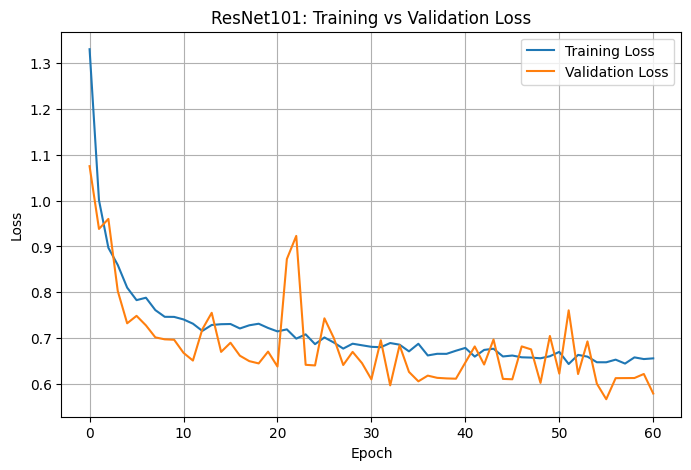

Saved plot to /kaggle/working/final_project_outputs/plots/ResNet101_loss_curve.png
Best model saved to: /kaggle/working/final_project_outputs/saved_models/ResNet101_best.keras


In [12]:
resnet101_model = build_transfer_model(
    base_model_class=ResNet101,
    preprocess_input_function=resnet_preprocess,
    model_name="ResNet101"
)

resnet101_model, resnet101_history = train_model_with_required_epochs(
    model=resnet101_model,
    model_name="ResNet101",
    train_ds=train_ds,
    val_ds=val_ds
)

In [13]:
print("Saved models:")
for file in sorted(SAVED_MODELS_DIR.glob("ResNet101")):
    print(file.name, round(file.stat().st_size / (1024 * 1024), 2), "MB")

print("\nPlots:")
for file in sorted(PLOTS_DIR.glob("ResNet101")):
    print(file.name, round(file.stat().st_size / 1024, 2), "KB")

print("\nResults:")
for file in sorted(RESULTS_DIR.glob("ResNet101")):
    print(file.name, round(file.stat().st_size / 1024, 2), "KB")


Saved models:

Plots:

Results:


In [14]:
import os

search_root = "/kaggle/working"
found_files = []

for root, dirs, files in os.walk(search_root):
    for file in files:
        if "ResNet101" in file:
            found_files.append(os.path.join(root, file))

print("ResNet101-related files found:")
for file in found_files:
    print(file)

print("Total files found:", len(found_files))

ResNet101-related files found:
/kaggle/working/final_project_outputs/results/ResNet101_history.pkl
/kaggle/working/final_project_outputs/saved_models/ResNet101_best.keras
/kaggle/working/final_project_outputs/plots/ResNet101_loss_curve.png
Total files found: 3


In [15]:
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/final_project_outputs")

SAVED_MODELS_DIR = OUTPUT_DIR / "saved_models"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

print("Saved models exists:", SAVED_MODELS_DIR.exists())
print("Plots exists:", PLOTS_DIR.exists())
print("Results exists:", RESULTS_DIR.exists())

Saved models exists: True
Plots exists: True
Results exists: True


In [16]:
for file in [
    SAVED_MODELS_DIR / "ResNet101_best.keras",
    PLOTS_DIR / "ResNet101_loss_curve.png",
    RESULTS_DIR / "ResNet101_history.pkl",
]:
    print(
        file.name,
        "exists:", file.exists(),
        "size:", round(file.stat().st_size / (1024 * 1024), 2),
        "MB"
    )

ResNet101_best.keras exists: True size: 170.0 MB
ResNet101_loss_curve.png exists: True size: 0.04 MB
ResNet101_history.pkl exists: True size: 0.0 MB


16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1 for EfficientNetB0: training for required 50 epochs.
Epoch 1/50


E0000 00:00:1778280515.233049      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/EfficientNetB0_1/efficientnetb0_1/block2b_drop_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - accuracy: 0.5635 - loss: 1.6597
Epoch 1: val_loss improved from inf to 1.13823, saving model to /kaggle/working/final_project_outputs/saved_models/EfficientNetB0_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 34s 110ms/step - accuracy: 0.5638 - loss: 1.6586 - val_accuracy: 0.6723 - val_loss: 1.1382
Epoch 2/50
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6752 - loss: 1.1832
Epoch 2: val_loss improved from 1.13823 to 1.13557, saving model to /kaggle/working/final_project_outputs/saved_models/EfficientNetB0_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.6752 - loss: 1.1829 - val_accuracy: 0.7045 - val_loss: 1.1356
Epoch 3/50
213/214 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step - accuracy: 0.6999 - loss: 1.0803
Epoch 3: val_loss improved from 1.13557 to 1.02900, saving model to /kaggle/working/final_project_outputs/saved_models/EfficientNetB0_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 20s 95ms/step - accuracy: 0.6999 - loss: 1.0801 - v

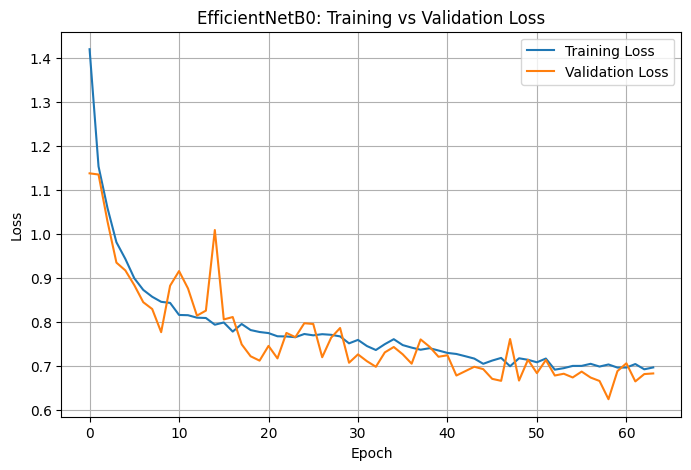

Saved plot to /kaggle/working/final_project_outputs/plots/EfficientNetB0_loss_curve.png
Best model saved to: /kaggle/working/final_project_outputs/saved_models/EfficientNetB0_best.keras


In [17]:
efficientnet_model = build_transfer_model(
    base_model_class=EfficientNetB0,
    preprocess_input_function=efficientnet_preprocess,
    model_name="EfficientNetB0"
)

efficientnet_model, efficientnet_history = train_model_with_required_epochs(
    model=efficientnet_model,
    model_name="EfficientNetB0",
    train_ds=train_ds,
    val_ds=val_ds
)

In [18]:
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/final_project_outputs")

SAVED_MODELS_DIR = OUTPUT_DIR / "saved_models"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

files_to_check = [
    SAVED_MODELS_DIR / "EfficientNetB0_best.keras",
    PLOTS_DIR / "EfficientNetB0_loss_curve.png",
    RESULTS_DIR / "EfficientNetB0_history.pkl",
]

for file in files_to_check:
    print(
        file.name,
        "exists:", file.exists(),
        "size:", round(file.stat().st_size / (1024 * 1024), 2),
        "MB"
    )

EfficientNetB0_best.keras exists: True size: 20.06 MB
EfficientNetB0_loss_curve.png exists: True size: 0.04 MB
EfficientNetB0_history.pkl exists: True size: 0.0 MB


74836368/74836368 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
Phase 1 for DenseNet201: training for required 50 epochs.
Epoch 1/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.5815 - loss: 1.4314
Epoch 1: val_loss improved from inf to 0.88919, saving model to /kaggle/working/final_project_outputs/saved_models/DenseNet201_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 93s 329ms/step - accuracy: 0.5818 - loss: 1.4302 - val_accuracy: 0.6943 - val_loss: 0.8892
Epoch 2/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 236ms/step - accuracy: 0.6930 - loss: 0.9473
Epoch 2: val_loss did not improve from 0.88919
214/214 ━━━━━━━━━━━━━━━━━━━━ 60s 281ms/step - accuracy: 0.6930 - loss: 0.9472 - val_accuracy: 0.6804 - val_loss: 1.0668
Epoch 3/50
214/214 ━━━━━━━━━━━━━━━━━━━━ 0s 243ms/step - accuracy: 0.7081 - loss: 0.8845
Epoch 3: val_loss improved from 0.88919 to 0.77736, saving model to /kaggle/working/final_project_outputs/saved_models/DenseNet201_best.keras
214/214 ━━━━━━━━━━━━━━━━━━━━ 64s 298ms/step - accuracy: 0.70

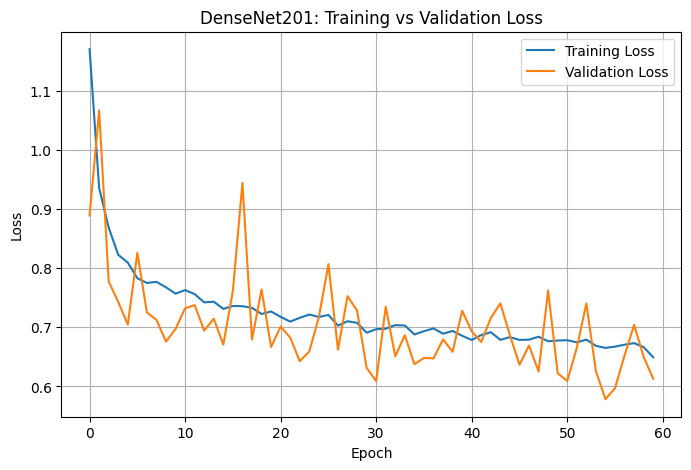

Saved plot to /kaggle/working/final_project_outputs/plots/DenseNet201_loss_curve.png
Best model saved to: /kaggle/working/final_project_outputs/saved_models/DenseNet201_best.keras


In [19]:
densenet_model = build_transfer_model(
    base_model_class=DenseNet201,
    preprocess_input_function=densenet_preprocess,
    model_name="DenseNet201"
)

densenet_model, densenet_history = train_model_with_required_epochs(
    model=densenet_model,
    model_name="DenseNet201",
    train_ds=train_ds,
    val_ds=val_ds
)

In [20]:
from pathlib import Path

OUTPUT_DIR = Path("/kaggle/working/final_project_outputs")

SAVED_MODELS_DIR = OUTPUT_DIR / "saved_models"
PLOTS_DIR = OUTPUT_DIR / "plots"
RESULTS_DIR = OUTPUT_DIR / "results"

files_to_check = [
    SAVED_MODELS_DIR / "DenseNet201_best.keras",
    PLOTS_DIR / "DenseNet201_loss_curve.png",
    RESULTS_DIR / "DenseNet201_history.pkl",
]

for file in files_to_check:
    print(
        file.name,
        "exists:", file.exists(),
        "size:", round(file.stat().st_size / (1024 * 1024), 2),
        "MB"
    )

DenseNet201_best.keras exists: True size: 77.96 MB
DenseNet201_loss_curve.png exists: True size: 0.05 MB
DenseNet201_history.pkl exists: True size: 0.0 MB


In [22]:
import shutil

output_zip = "/kaggle/working/final_project_outputs.zip"

shutil.make_archive(
    base_name="/kaggle/working/final_project_outputs",
    format="zip",
    root_dir="/kaggle/working/final_project_outputs"
)

print("Created:", output_zip)

Created: /kaggle/working/final_project_outputs.zip


In [23]:
from pathlib import Path

zip_path = Path("/kaggle/working/final_project_outputs.zip")

print("Zip exists:", zip_path.exists())
print("Zip size MB:", round(zip_path.stat().st_size / (1024 * 1024), 2))

Zip exists: True
Zip size MB: 246.23


In [24]:
from pathlib import Path

saved_models_dir = Path("/kaggle/working/final_project_outputs/saved_models")

print("Folder exists:", saved_models_dir.exists())

if saved_models_dir.exists():
    for file in sorted(saved_models_dir.glob("*.keras")):
        print(file.name)

Folder exists: True
DenseNet201_best.keras
EfficientNetB0_best.keras
ResNet101_best.keras


In [25]:
!git lfs install
!git clone https://github.com/ndreaelizabth/dsci552_finalproject_spring_2026.git /kaggle/working/final_repo


Git LFS initialized.
Cloning into '/kaggle/working/final_repo'...
remote: Enumerating objects: 9129, done.
remote: Counting objects: 100% (19/19), done.
remote: Compressing objects: 100% (16/16), done.
remote: Total 9129 (delta 2), reused 15 (delta 2), pack-reused 9110 (from 3)
Receiving objects: 100% (9129/9129), 379.07 MiB | 40.40 MiB/s, done.
Resolving deltas: 100% (13/13), done.
Filtering content: 100% (5/5), 422.47 MiB | 24.41 MiB/s, done.


In [26]:
from pathlib import Path

repo_models_dir = Path("/kaggle/working/final_repo/notebook/saved_models")

print("Repo models folder exists:", repo_models_dir.exists())

for file in sorted(repo_models_dir.glob("*.keras")):
    print(file.name, round(file.stat().st_size / (1024 * 1024), 2), "MB")

Repo models folder exists: True
DenseNet201_best.keras 77.96 MB
EfficientNetB0_best.keras 20.06 MB
ResNet101_best.keras 170.0 MB
ResNet50_best.keras 96.67 MB
VGG16_best.keras 57.78 MB


In [27]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras

from pathlib import Path
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

# Recreate non-shuffled datasets for clean evaluation
train_eval_ds = keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

val_eval_ds = keras.utils.image_dataset_from_directory(
    VAL_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

test_eval_ds = keras.utils.image_dataset_from_directory(
    TEST_DIR,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="categorical",
    shuffle=False
)

AUTOTUNE = tf.data.AUTOTUNE
train_eval_ds = train_eval_ds.prefetch(buffer_size=AUTOTUNE)
val_eval_ds = val_eval_ds.prefetch(buffer_size=AUTOTUNE)
test_eval_ds = test_eval_ds.prefetch(buffer_size=AUTOTUNE)

print("Evaluation datasets ready.")
print("Class names:", class_names)

Found 6834 files belonging to 5 classes.
Found 1364 files belonging to 5 classes.
Found 916 files belonging to 5 classes.
Evaluation datasets ready.
Class names: ['C1', 'C2', 'C3', 'C4', 'C5']


In [29]:
def get_true_labels(dataset):
    y_true = []

    for images, labels in dataset:
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(y_true)


def evaluate_model_on_dataset(model, dataset, split_name):
    y_true = get_true_labels(dataset)

    y_prob = model.predict(dataset, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    try:
        y_true_onehot = keras.utils.to_categorical(y_true, num_classes=len(class_names))
        auc = roc_auc_score(
            y_true_onehot,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    except Exception as e:
        print(f"AUC could not be calculated for {split_name}:", e)
        auc = np.nan

    return {
        "Split": split_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }


model_files = {
    "VGG16": repo_models_dir / "VGG16_best.keras",
    "ResNet50": repo_models_dir / "ResNet50_best.keras",
    "ResNet101": repo_models_dir / "ResNet101_best.keras",
    "EfficientNetB0": repo_models_dir / "EfficientNetB0_best.keras",
    "DenseNet201": repo_models_dir / "DenseNet201_best.keras",
}

all_metrics = []

for model_name, model_path in model_files.items():
    print("\n" + "=" * 60)
    print("Loading model:", model_name)
    print("Path:", model_path)

    model = keras.models.load_model(model_path)

    for split_name, dataset in [
        ("Train", train_eval_ds),
        ("Validation", val_eval_ds),
        ("Test", test_eval_ds),
    ]:
        print(f"\nEvaluating {model_name} on {split_name} set...")
        metrics = evaluate_model_on_dataset(model, dataset, split_name)
        metrics["Model"] = model_name
        all_metrics.append(metrics)

    tf.keras.backend.clear_session()

metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df[["Model", "Split", "Precision", "Recall", "F1", "AUC"]]

metrics_df


Loading model: VGG16
Path: /kaggle/working/final_repo/notebook/saved_models/VGG16_best.keras


TypeError: <class 'keras.src.models.functional.Functional'> could not be deserialized properly. Please ensure that components that are Python object instances (layers, models, etc.) returned by `get_config()` are explicitly deserialized in the model's `from_config()` method.

config={'module': 'keras.src.models.functional', 'class_name': 'Functional', 'config': {}, 'registered_name': 'Functional', 'build_config': {'input_shape': None}, 'compile_config': {'optimizer': {'module': 'keras.optimizers', 'class_name': 'Adam', 'config': {'name': 'adam', 'learning_rate': 0.0010000000474974513, 'weight_decay': None, 'clipnorm': None, 'global_clipnorm': None, 'clipvalue': None, 'use_ema': False, 'ema_momentum': 0.99, 'ema_overwrite_frequency': None, 'loss_scale_factor': None, 'gradient_accumulation_steps': None, 'beta_1': 0.9, 'beta_2': 0.999, 'epsilon': 1e-07, 'amsgrad': False}, 'registered_name': None}, 'loss': 'categorical_crossentropy', 'loss_weights': None, 'metrics': ['accuracy'], 'weighted

In [30]:
import zipfile
import tempfile
from pathlib import Path

def load_weights_from_keras_file(model, keras_file_path):
    """
    Loads weights from a .keras file without loading the full saved model.
    This avoids Keras version deserialization issues.
    """
    keras_file_path = Path(keras_file_path)

    temp_dir = Path(tempfile.mkdtemp())

    with zipfile.ZipFile(keras_file_path, "r") as zip_ref:
        zip_ref.extractall(temp_dir)

    weights_path = temp_dir / "model.weights.h5"

    if not weights_path.exists():
        print("Files inside extracted .keras:")
        for file in temp_dir.rglob("*"):
            print(file)
        raise FileNotFoundError("model.weights.h5 was not found inside the .keras file.")

    model.load_weights(weights_path)
    return model

print("Weight-loading helper is ready.")

Weight-loading helper is ready.


In [32]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers

from tensorflow.keras.applications import VGG16, ResNet50, ResNet101, EfficientNetB0, DenseNet201
from tensorflow.keras.applications.vgg16 import preprocess_input as vgg16_preprocess
from tensorflow.keras.applications.resnet import preprocess_input as resnet_preprocess
from tensorflow.keras.applications.efficientnet import preprocess_input as efficientnet_preprocess
from tensorflow.keras.applications.densenet import preprocess_input as densenet_preprocess

print("Model imports are ready.")
print("GPU:", tf.config.list_physical_devices("GPU"))

Model imports are ready.
GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU'), PhysicalDevice(name='/physical_device:GPU:1', device_type='GPU')]


In [33]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

def get_true_labels(dataset):
    y_true = []

    for images, labels in dataset:
        y_true.extend(np.argmax(labels.numpy(), axis=1))

    return np.array(y_true)


def evaluate_model_on_dataset(model, dataset, split_name):
    y_true = get_true_labels(dataset)

    y_prob = model.predict(dataset, verbose=1)
    y_pred = np.argmax(y_prob, axis=1)

    precision = precision_score(y_true, y_pred, average="weighted", zero_division=0)
    recall = recall_score(y_true, y_pred, average="weighted", zero_division=0)
    f1 = f1_score(y_true, y_pred, average="weighted", zero_division=0)

    try:
        y_true_onehot = keras.utils.to_categorical(y_true, num_classes=len(class_names))
        auc = roc_auc_score(
            y_true_onehot,
            y_prob,
            multi_class="ovr",
            average="weighted"
        )
    except Exception as e:
        print(f"AUC could not be calculated for {split_name}:", e)
        auc = np.nan

    return {
        "Split": split_name,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "AUC": auc
    }

print("Metric helper functions are ready.")

Metric helper functions are ready.


In [34]:
model_specs = {
    "VGG16": {
        "path": repo_models_dir / "VGG16_best.keras",
        "class": VGG16,
        "preprocess": vgg16_preprocess,
    },
    "ResNet50": {
        "path": repo_models_dir / "ResNet50_best.keras",
        "class": ResNet50,
        "preprocess": resnet_preprocess,
    },
    "ResNet101": {
        "path": repo_models_dir / "ResNet101_best.keras",
        "class": ResNet101,
        "preprocess": resnet_preprocess,
    },
    "EfficientNetB0": {
        "path": repo_models_dir / "EfficientNetB0_best.keras",
        "class": EfficientNetB0,
        "preprocess": efficientnet_preprocess,
    },
    "DenseNet201": {
        "path": repo_models_dir / "DenseNet201_best.keras",
        "class": DenseNet201,
        "preprocess": densenet_preprocess,
    },
}

all_metrics = []

for model_name, spec in model_specs.items():
    print("\n" + "=" * 60)
    print("Rebuilding model:", model_name)
    print("Loading weights from:", spec["path"])

    model = build_transfer_model(
        base_model_class=spec["class"],
        preprocess_input_function=spec["preprocess"],
        model_name=model_name
    )

    model = load_weights_from_keras_file(model, spec["path"])

    for split_name, dataset in [
        ("Train", train_eval_ds),
        ("Validation", val_eval_ds),
        ("Test", test_eval_ds),
    ]:
        print(f"\nEvaluating {model_name} on {split_name} set...")
        metrics = evaluate_model_on_dataset(model, dataset, split_name)
        metrics["Model"] = model_name
        all_metrics.append(metrics)

    tf.keras.backend.clear_session()

metrics_df = pd.DataFrame(all_metrics)
metrics_df = metrics_df[["Model", "Split", "Precision", "Recall", "F1", "AUC"]]

metrics_df


Rebuilding model: VGG16
Loading weights from: /kaggle/working/final_repo/notebook/saved_models/VGG16_best.keras
58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Evaluating VGG16 on Train set...
214/214 ━━━━━━━━━━━━━━━━━━━━ 33s 138ms/step

Evaluating VGG16 on Validation set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 8s 188ms/step

Evaluating VGG16 on Test set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 135ms/step

Rebuilding model: ResNet50
Loading weights from: /kaggle/working/final_repo/notebook/saved_models/ResNet50_best.keras
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Evaluating ResNet50 on Train set...
214/214 ━━━━━━━━━━━━━━━━━━━━ 31s 137ms/step

Evaluating ResNet50 on Validation set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 6s 130ms/step

Evaluating ResNet50 on Test set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 4s 130ms/step

Rebuilding model: ResNet101
Loading weights from: /kaggle/working/final_repo/notebook/saved_models/ResNet101_best.keras


...

/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Evaluating EfficientNetB0 on Train set...
214/214 ━━━━━━━━━━━━━━━━━━━━ 21s 86ms/step

Evaluating EfficientNetB0 on Validation set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 3s 73ms/step

Evaluating EfficientNetB0 on Test set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 2s 73ms/step

Rebuilding model: DenseNet201
Loading weights from: /kaggle/working/final_repo/notebook/saved_models/DenseNet201_best.keras


/usr/local/lib/python3.12/dist-packages/keras/src/saving/saving_lib.py:802: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 14 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))



Evaluating DenseNet201 on Train set...
214/214 ━━━━━━━━━━━━━━━━━━━━ 62s 261ms/step

Evaluating DenseNet201 on Validation set...
43/43 ━━━━━━━━━━━━━━━━━━━━ 10s 225ms/step

Evaluating DenseNet201 on Test set...
29/29 ━━━━━━━━━━━━━━━━━━━━ 7s 225ms/step


,Model,Split,Precision,Recall,F1,AUC
0,VGG16,Train,0.758728,0.762365,0.751741,0.902493
1,VGG16,Validation,0.748554,0.752933,0.742886,0.903712
2,VGG16,Test,0.735212,0.747817,0.732701,0.895956
3,ResNet50,Train,0.788842,0.788850,0.778074,0.914200
4,ResNet50,Validation,0.784947,0.784457,0.770440,0.926768
5,ResNet50,Test,0.803331,0.803493,0.790987,0.917103
6,ResNet101,Train,0.828363,0.829529,0.825048,0.943695
7,ResNet101,Validation,0.800966,0.804985,0.798975,0.931155
8,ResNet101,Test,0.802650,0.807860,0.801927,0.935046
9,EfficientNetB0,Train,0.787661,0.787826,0.778153,0.918166


In [35]:
metrics_output_path = "/kaggle/working/final_project_outputs/results/metrics_summary.csv"

metrics_df.to_csv(metrics_output_path, index=False)

print("Saved metrics table to:", metrics_output_path)
metrics_df

Saved metrics table to: /kaggle/working/final_project_outputs/results/metrics_summary.csv


,Model,Split,Precision,Recall,F1,AUC
0,VGG16,Train,0.758728,0.762365,0.751741,0.902493
1,VGG16,Validation,0.748554,0.752933,0.742886,0.903712
2,VGG16,Test,0.735212,0.747817,0.732701,0.895956
3,ResNet50,Train,0.788842,0.788850,0.778074,0.914200
4,ResNet50,Validation,0.784947,0.784457,0.770440,0.926768
5,ResNet50,Test,0.803331,0.803493,0.790987,0.917103
6,ResNet101,Train,0.828363,0.829529,0.825048,0.943695
7,ResNet101,Validation,0.800966,0.804985,0.798975,0.931155
8,ResNet101,Test,0.802650,0.807860,0.801927,0.935046
9,EfficientNetB0,Train,0.787661,0.787826,0.778153,0.918166


In [36]:
from pathlib import Path

metrics_file = Path("/kaggle/working/final_project_outputs/results/metrics_summary.csv")

print("Metrics file exists:", metrics_file.exists())
print("Size KB:", round(metrics_file.stat().st_size / 1024, 2))

Metrics file exists: True
Size KB: 1.4
